In [1]:
# 必要なライブラリのインポート
import sys
import pickle
import json
import yaml
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# プロジェクトのsrcディレクトリをパスに追加
sys.path.append('../src')

# 設定
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print(f"検証開始時刻: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)


検証開始時刻: 2025-07-15 05:40:10


In [2]:
# 設定ファイルの読み込み
config_path = Path("../config/config_v2.yaml")
cache_dir = Path("../cache")
output_dir = Path("../output")

print("### 設定ファイル確認")
if config_path.exists():
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    
    print(f"✓ 設定ファイル: {config_path}")
    print(f"✓ データディレクトリ: {config.get('data_dir', 'N/A')}")
    print(f"✓ キャッシュディレクトリ: {config.get('cache_dir', 'N/A')}")
    print(f"✓ 出力ディレクトリ: {config.get('output_dir', 'N/A')}")
    
    # 前処理パラメータの表示
    preprocessing_config = config.get('preprocessing', {})
    print("\n### 前処理パラメータ")
    print(f"✓ ウィンドウサイズ: {preprocessing_config.get('window_size', 'N/A')}")
    print(f"✓ ストライド: {preprocessing_config.get('stride', 'N/A')}")
    print(f"✓ 最小シーケンス長: {preprocessing_config.get('min_sequence_length', 'N/A')}")
    print(f"✓ サンプリングレート: {preprocessing_config.get('sampling_rate', 'N/A')}")
    print(f"✓ ToF深度: {preprocessing_config.get('tof_depth', 'N/A')}")
    print(f"✓ ToF高さ×幅: {preprocessing_config.get('tof_height', 'N/A')} × {preprocessing_config.get('tof_width', 'N/A')}")
else:
    print(f"❌ 設定ファイルが見つかりません: {config_path}")
    
print("\n### キャッシュファイル確認")
cache_files = {
    "ウィンドウテンソル": "windows.pkl",
    "表形式特徴量": "tabular_features.pkl", 
    "ToFボクセル": "tof_voxel.pkl",
    "ToFウィンドウ": "tof_windows.pkl"
}

for name, filename in cache_files.items():
    file_path = cache_dir / filename
    meta_path = cache_dir / f"{filename.replace('.pkl', '_meta.json')}"
    
    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 * 1024)
        print(f"✓ {name}: {filename} ({size_mb:.2f} MB)")
        
        # メタデータの確認
        if meta_path.exists():
            try:
                with open(meta_path, 'r') as f:
                    meta = json.load(f)
                print(f"  └ MD5: {meta.get('md5', 'N/A')[:8]}...")
            except:
                print(f"  └ メタデータ読み込み失敗")
        else:
            print(f"  └ メタデータなし")
    else:
        print(f"❌ {name}: {filename} (見つかりません)")

print("\n### 出力ディレクトリ確認")  
if output_dir.exists():
    experiments = list(output_dir.glob("experiments/*/"))
    if experiments:
        print(f"✓ 実験ディレクトリ数: {len(experiments)}")
        for exp_dir in experiments:
            preprocessed_dir = exp_dir / "preprocessed"
            if preprocessed_dir.exists():
                files = list(preprocessed_dir.glob("*.pkl"))
                print(f"  └ {exp_dir.name}: {len(files)} ファイル")
            else:
                print(f"  └ {exp_dir.name}: preprocessedディレクトリなし")
    else:
        print("❌ 実験ディレクトリが見つかりません")
else:
    print(f"❌ 出力ディレクトリが見つかりません: {output_dir}")


### 設定ファイル確認
✓ 設定ファイル: ../config/config_v2.yaml
✓ データディレクトリ: data
✓ キャッシュディレクトリ: cache
✓ 出力ディレクトリ: output/experiments

### 前処理パラメータ
✓ ウィンドウサイズ: 128
✓ ストライド: 64
✓ 最小シーケンス長: 20
✓ サンプリングレート: 50.0
✓ ToF深度: 5
✓ ToF高さ×幅: 8 × 8

### キャッシュファイル確認
✓ ウィンドウテンソル: windows.pkl (0.01 MB)
  └ MD5: 2db51efe...
✓ 表形式特徴量: tabular_features.pkl (0.00 MB)
  └ メタデータなし
✓ ToFボクセル: tof_voxel.pkl (0.13 MB)
  └ メタデータなし
✓ ToFウィンドウ: tof_windows.pkl (0.31 MB)
  └ MD5: 2db51efe...

### 出力ディレクトリ確認
✓ 実験ディレクトリ数: 18
  └ 20250713_preproc_pipeline_first_try: 15 ファイル
  └ baseline_lightgbm_v1: preprocessedディレクトリなし
  └ debug_test_w64_s16: preprocessedディレクトリなし
  └ final_model_w64_s16: preprocessedディレクトリなし
  └ lstm_v1: 4 ファイル
  └ lstm_v2_cmi_optimization: preprocessedディレクトリなし
  └ lstm_v2_hybrid_w64_s16: preprocessedディレクトリなし
  └ lstm_v2_hyperopt_resume_w64_s16: preprocessedディレクトリなし
  └ lstm_v2_hyperopt_w64_s16: preprocessedディレクトリなし
  └ lstm_v2_optimization: preprocessedディレクトリなし
  └ lstm_v2_optimized: preprocessedディレクトリなし
  └ lstm

In [3]:
# 生データの読み込みと基本統計
data_dir = Path("../data")

print("### 生データファイル確認")
raw_files = {
    "train.csv": "訓練データ",
    "test.csv": "テストデータ", 
    "train_demographics.csv": "訓練人口統計",
    "test_demographics.csv": "テスト人口統計"
}

for filename, description in raw_files.items():
    file_path = data_dir / filename
    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 * 1024)
        print(f"✓ {description}: {filename} ({size_mb:.2f} MB)")
    else:
        print(f"❌ {description}: {filename} (見つかりません)")

# サンプルデータの読み込み（メモリ効率のため）
print("\n### データ形状とサンプル統計")
try:
    # 訓練データのサンプルを読み込み（最初の1000行のみ）
    train_sample = pd.read_csv(data_dir / "train.csv", nrows=1000)
    
    print(f"✓ 訓練データサンプル形状: {train_sample.shape}")
    print(f"✓ カラム数: {len(train_sample.columns)}")
    print(f"✓ ユニークsubject数: {train_sample['subject'].nunique()}")
    print(f"✓ ユニークsequence_id数: {train_sample['sequence_id'].nunique()}")
    
    if 'gesture' in train_sample.columns:
        print(f"✓ ユニークgesture数: {train_sample['gesture'].nunique()}")
        gesture_counts = train_sample['gesture'].value_counts()
        print(f"✓ ジェスチャー分布: {dict(gesture_counts.head())}")
    
    # センサー列の分類
    sensor_types = {
        'accelerometer': [col for col in train_sample.columns if col.startswith('acc_')],
        'rotation': [col for col in train_sample.columns if col.startswith('rot_')], 
        'tof': [col for col in train_sample.columns if col.startswith('tof_')],
        'thermal': [col for col in train_sample.columns if col.startswith('thm_')]
    }
    
    print("\n### センサー列数")
    for sensor_type, cols in sensor_types.items():
        print(f"✓ {sensor_type}: {len(cols)} 列")
        if len(cols) > 0:
            # 欠損値の確認
            missing_ratio = train_sample[cols].isnull().sum().sum() / (len(train_sample) * len(cols)) * 100
            print(f"  └ 欠損値率: {missing_ratio:.2f}%")
    
    # 人口統計データの確認
    if (data_dir / "train_demographics.csv").exists():
        demo_df = pd.read_csv(data_dir / "train_demographics.csv")
        print(f"\n### 人口統計データ")
        print(f"✓ 形状: {demo_df.shape}")
        print(f"✓ カラム: {list(demo_df.columns)}")
        
        # 基本統計
        if 'handedness' in demo_df.columns:
            handedness_dist = demo_df['handedness'].value_counts()
            print(f"✓ 利き手分布: {dict(handedness_dist)}")
        
        if 'adult_child' in demo_df.columns:
            age_dist = demo_df['adult_child'].value_counts()
            print(f"✓ 年齢層分布: {dict(age_dist)}")
            
except Exception as e:
    print(f"❌ データ読み込みエラー: {e}")

print("\n" + "="*60)


### 生データファイル確認
✓ 訓練データ: train.csv (1069.59 MB)
✓ テストデータ: test.csv (0.19 MB)
✓ 訓練人口統計: train_demographics.csv (0.00 MB)
✓ テスト人口統計: test_demographics.csv (0.00 MB)

### データ形状とサンプル統計
✓ 訓練データサンプル形状: (1000, 341)
✓ カラム数: 341
✓ ユニークsubject数: 14
✓ ユニークsequence_id数: 15
✓ ユニークgesture数: 10
✓ ジェスチャー分布: {'Forehead - pull hairline': 200, 'Feel around in tray and pull out an object': 159, 'Eyelash - pull hair': 138, 'Above ear - pull hair': 115, 'Cheek - pinch skin': 110}

### センサー列数
✓ accelerometer: 3 列
  └ 欠損値率: 0.00%
✓ rotation: 4 列
  └ 欠損値率: 0.00%
✓ tof: 320 列
  └ 欠損値率: 0.00%
✓ thermal: 5 列
  └ 欠損値率: 0.00%

### 人口統計データ
✓ 形状: (81, 8)
✓ カラム: ['subject', 'adult_child', 'age', 'sex', 'handedness', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm']
✓ 利き手分布: {1: 71, 0: 10}
✓ 年齢層分布: {1: 42, 0: 39}



In [4]:
# 中間キャッシュファイルの詳細確認
def load_cache_safely(cache_path, description):
    """キャッシュファイルを安全に読み込み"""
    if not cache_path.exists():
        print(f"❌ {description}: ファイルが存在しません ({cache_path})")
        return None
    
    try:
        with open(cache_path, 'rb') as f:
            data = pickle.load(f)
        print(f"✓ {description}: 読み込み成功")
        return data
    except Exception as e:
        print(f"❌ {description}: 読み込み失敗 - {e}")
        return None

print("### 中間キャッシュファイルの詳細分析")
print("="*50)

# 1. ウィンドウテンソル (windows.pkl)
print("\n### 1. ウィンドウテンソル")
windows_data = load_cache_safely(cache_dir / "windows.pkl", "ウィンドウテンソル")
if windows_data is not None:
    if isinstance(windows_data, (list, tuple)) and len(windows_data) >= 4:
        X_sensor, X_demo, y, info = windows_data[:4]
        
        print(f"  ✓ X_sensor (センサーウィンドウ): {X_sensor.shape} {X_sensor.dtype}")
        print(f"  ✓ X_demo (人口統計): {X_demo.shape} {X_demo.dtype}")
        print(f"  ✓ y (ラベル): {y.shape} {y.dtype}")
        print(f"  ✓ info (メタ情報): {len(info)} 件")
        
        # 基本統計
        print(f"  ✓ センサーデータ範囲: [{np.nanmin(X_sensor):.3f}, {np.nanmax(X_sensor):.3f}]")
        print(f"  ✓ NaN値: {np.isnan(X_sensor).sum()} / {X_sensor.size} ({np.isnan(X_sensor).sum()/X_sensor.size*100:.2f}%)")
        print(f"  ✓ ユニークラベル数: {len(np.unique(y))}")
        
        # サンプルのinfo確認
        if len(info) > 0:
            sample_info = info[0]
            print(f"  ✓ サンプルinfo: {sample_info}")
    else:
        print(f"  ❌ 予期しないデータ構造: {type(windows_data)}")

# 2. 表形式特徴量 (tabular_features.pkl)
print("\n### 2. 表形式特徴量")
tabular_data = load_cache_safely(cache_dir / "tabular_features.pkl", "表形式特徴量")
if tabular_data is not None:
    if isinstance(tabular_data, (list, tuple)) and len(tabular_data) >= 3:
        features, y_tab, info_tab = tabular_data[:3]
        
        print(f"  ✓ features: {features.shape} {features.dtype}")
        print(f"  ✓ y: {y_tab.shape} {y_tab.dtype}")
        print(f"  ✓ info: {len(info_tab)} 件")
        
        # 基本統計
        print(f"  ✓ 特徴量範囲: [{np.nanmin(features):.3f}, {np.nanmax(features):.3f}]")
        print(f"  ✓ NaN値: {np.isnan(features).sum()} / {features.size} ({np.isnan(features).sum()/features.size*100:.2f}%)")
        
        # 特徴量の分布確認
        if features.shape[1] > 0:
            feature_means = np.nanmean(features, axis=0)
            feature_stds = np.nanstd(features, axis=0)
            print(f"  ✓ 特徴量平均の範囲: [{np.min(feature_means):.3f}, {np.max(feature_means):.3f}]")
            print(f"  ✓ 特徴量標準偏差の範囲: [{np.min(feature_stds):.3f}, {np.max(feature_stds):.3f}]")
    else:
        print(f"  ❌ 予期しないデータ構造: {type(tabular_data)}")

# 3. ToFボクセル (tof_voxel.pkl)
print("\n### 3. ToFボクセル")
tof_voxel_data = load_cache_safely(cache_dir / "tof_voxel.pkl", "ToFボクセル")
if tof_voxel_data is not None:
    print(f"  ✓ ToFボクセル: {tof_voxel_data.shape} {tof_voxel_data.dtype}")
    print(f"  ✓ 値の範囲: [{np.nanmin(tof_voxel_data):.3f}, {np.nanmax(tof_voxel_data):.3f}]")
    print(f"  ✓ NaN値: {np.isnan(tof_voxel_data).sum()} / {tof_voxel_data.size} ({np.isnan(tof_voxel_data).sum()/tof_voxel_data.size*100:.2f}%)")
    
    # 特殊値の確認
    zero_count = (tof_voxel_data == 0).sum()
    neg_one_count = (tof_voxel_data == -1).sum()
    print(f"  ✓ ゼロ値: {zero_count} / {tof_voxel_data.size} ({zero_count/tof_voxel_data.size*100:.2f}%)")
    print(f"  ✓ -1値: {neg_one_count} / {tof_voxel_data.size} ({neg_one_count/tof_voxel_data.size*100:.2f}%)")

# 4. ToFウィンドウ (tof_windows.pkl)
print("\n### 4. ToFウィンドウ")
tof_windows_data = load_cache_safely(cache_dir / "tof_windows.pkl", "ToFウィンドウ")
if tof_windows_data is not None:
    if isinstance(tof_windows_data, (list, tuple)) and len(tof_windows_data) >= 3:
        tof_X, tof_y, tof_info = tof_windows_data[:3]
        
        print(f"  ✓ ToF X: {tof_X.shape} {tof_X.dtype}")
        print(f"  ✓ ToF y: {tof_y.shape} {tof_y.dtype}")
        print(f"  ✓ ToF info: {len(tof_info)} 件")
        
        # 基本統計
        print(f"  ✓ ToFデータ範囲: [{np.nanmin(tof_X):.3f}, {np.nanmax(tof_X):.3f}]")
        print(f"  ✓ NaN値: {np.isnan(tof_X).sum()} / {tof_X.size} ({np.isnan(tof_X).sum()/tof_X.size*100:.2f}%)")
    else:
        print(f"  ❌ 予期しないデータ構造: {type(tof_windows_data)}")

print("\n" + "="*60)


### 中間キャッシュファイルの詳細分析

### 1. ウィンドウテンソル
✓ ウィンドウテンソル: 読み込み成功
  ✓ X_sensor (センサーウィンドウ): (2, 128, 12) float32
  ✓ X_demo (人口統計): (2, 7) float32
  ✓ y (ラベル): (2,) int64
  ✓ info (メタ情報): 2 件
  ✓ センサーデータ範囲: [-5.258, 33.649]
  ✓ NaN値: 0 / 3072 (0.00%)
  ✓ ユニークラベル数: 1
  ✓ サンプルinfo: {'subject': 'SUBJ_016452', 'sequence_id': 'SEQ_000011', 'start_idx': 0, 'end_idx': 128, 'padded': True}

### 2. 表形式特徴量
✓ 表形式特徴量: 読み込み成功
  ✓ features: (2, 129) float64
  ✓ y: (2,) int64
  ✓ info: 2 件
  ✓ 特徴量範囲: [-0.966, 291752.137]
  ✓ NaN値: 0 / 258 (0.00%)
  ✓ 特徴量平均の範囲: [-0.291, 235590.163]
  ✓ 特徴量標準偏差の範囲: [0.000, 56161.974]

### 3. ToFボクセル
✓ ToFボクセル: 読み込み成功
  ✓ ToFボクセル: (107, 5, 8, 8) float32
  ✓ 値の範囲: [0.000, 249.000]
  ✓ NaN値: 0 / 34240 (0.00%)
  ✓ ゼロ値: 16953 / 34240 (49.51%)
  ✓ -1値: 0 / 34240 (0.00%)

### 4. ToFウィンドウ
✓ ToFウィンドウ: 読み込み成功
  ❌ 予期しないデータ構造: <class 'tuple'>



In [5]:
# 前処理済みデータの確認
def find_latest_experiment():
    """最新の実験ディレクトリを見つける"""
    experiments_dir = Path("../output/experiments")
    if not experiments_dir.exists():
        return None
    
    exp_dirs = [d for d in experiments_dir.iterdir() if d.is_dir()]
    if not exp_dirs:
        return None
    
    # 最新の実験を選択（ディレクトリ名でソート）
    latest_exp = sorted(exp_dirs)[-1]
    preprocessed_dir = latest_exp / "preprocessed"
    
    if preprocessed_dir.exists():
        return preprocessed_dir
    return None

print("### 前処理済みデータの確認")
print("="*50)

preprocessed_dir = find_latest_experiment()
if preprocessed_dir is None:
    print("❌ 前処理済みデータが見つかりません")
else:
    print(f"✓ 前処理済みデータディレクトリ: {preprocessed_dir}")
    
    # 前処理済みファイルの一覧
    pkl_files = list(preprocessed_dir.glob("*.pkl"))
    log_files = list(preprocessed_dir.glob("*.log"))
    
    print(f"✓ PKLファイル数: {len(pkl_files)}")
    print(f"✓ ログファイル数: {len(log_files)}")
    
    # ファイルサイズの確認
    print("\n### ファイルサイズ")
    for pkl_file in sorted(pkl_files):
        size_mb = pkl_file.stat().st_size / (1024 * 1024)
        print(f"  ✓ {pkl_file.name}: {size_mb:.2f} MB")
    
    # 主要なファイルの内容確認
    print("\n### データ内容確認")
    
    # Train データ
    train_files = [f for f in pkl_files if f.name.startswith('train_')]
    if train_files:
        print(f"\n#### 訓練データファイル ({len(train_files)} 件)")
        for train_file in sorted(train_files):
            data_type = train_file.name.replace('train_', '').replace('.pkl', '')
            try:
                with open(train_file, 'rb') as f:
                    data = pickle.load(f)
                
                if isinstance(data, np.ndarray):
                    print(f"  ✓ {data_type}: {data.shape} {data.dtype}")
                    print(f"    └ 範囲: [{np.nanmin(data):.3f}, {np.nanmax(data):.3f}]")
                    nan_ratio = np.isnan(data).sum() / data.size * 100
                    print(f"    └ NaN率: {nan_ratio:.2f}%")
                else:
                    print(f"  ✓ {data_type}: {type(data)} (長さ: {len(data) if hasattr(data, '__len__') else 'N/A'})")
                    
            except Exception as e:
                print(f"  ❌ {data_type}: 読み込み失敗 - {e}")
    
    # Test データ
    test_files = [f for f in pkl_files if f.name.startswith('test_')]
    if test_files:
        print(f"\n#### テストデータファイル ({len(test_files)} 件)")
        for test_file in sorted(test_files):
            data_type = test_file.name.replace('test_', '').replace('.pkl', '')
            try:
                with open(test_file, 'rb') as f:
                    data = pickle.load(f)
                
                if isinstance(data, np.ndarray):
                    print(f"  ✓ {data_type}: {data.shape} {data.dtype}")
                    print(f"    └ 範囲: [{np.nanmin(data):.3f}, {np.nanmax(data):.3f}]")
                    nan_ratio = np.isnan(data).sum() / data.size * 100
                    print(f"    └ NaN率: {nan_ratio:.2f}%")
                else:
                    print(f"  ✓ {data_type}: {type(data)} (長さ: {len(data) if hasattr(data, '__len__') else 'N/A'})")
                    
            except Exception as e:
                print(f"  ❌ {data_type}: 読み込み失敗 - {e}")
    
    # Preprocessor の確認
    preprocessor_file = preprocessed_dir / "preprocessor.pkl"
    if preprocessor_file.exists():
        print(f"\n#### Preprocessor")
        try:
            with open(preprocessor_file, 'rb') as f:
                preprocessor = pickle.load(f)
            print(f"  ✓ Preprocessor: {type(preprocessor)}")
            print(f"  ✓ fitted: {getattr(preprocessor, '_fitted', 'N/A')}")
            
            # スケーラーの確認
            if hasattr(preprocessor, 'sensor_scaler'):
                print(f"  ✓ sensor_scaler: {type(preprocessor.sensor_scaler)}")
                if hasattr(preprocessor.sensor_scaler, 'scale_'):
                    print(f"    └ scale_範囲: [{np.min(preprocessor.sensor_scaler.scale_):.3f}, {np.max(preprocessor.sensor_scaler.scale_):.3f}]")
            
            if hasattr(preprocessor, 'demo_scaler'):
                print(f"  ✓ demo_scaler: {type(preprocessor.demo_scaler)}")
                if hasattr(preprocessor.demo_scaler, 'scale_'):
                    print(f"    └ scale_範囲: [{np.min(preprocessor.demo_scaler.scale_):.3f}, {np.max(preprocessor.demo_scaler.scale_):.3f}]")
                    
        except Exception as e:
            print(f"  ❌ Preprocessor読み込み失敗: {e}")
    
    # ログファイルの確認
    if log_files:
        print(f"\n#### ログファイル")
        for log_file in log_files:
            size_kb = log_file.stat().st_size / 1024
            print(f"  ✓ {log_file.name}: {size_kb:.1f} KB")
            
            # 最後の数行を表示
            try:
                with open(log_file, 'r', encoding='utf-8') as f:
                    lines = f.readlines()
                if len(lines) > 5:
                    print("    └ 最後の3行:")
                    for line in lines[-3:]:
                        print(f"      {line.strip()}")
            except Exception as e:
                print(f"    └ ログ読み込み失敗: {e}")

print("\n" + "="*60)


### 前処理済みデータの確認
❌ 前処理済みデータが見つかりません



### センサー別データの可視化
✓ センサーウィンドウ形状: (2, 128, 12)
✓ 想定センサー列数: 332


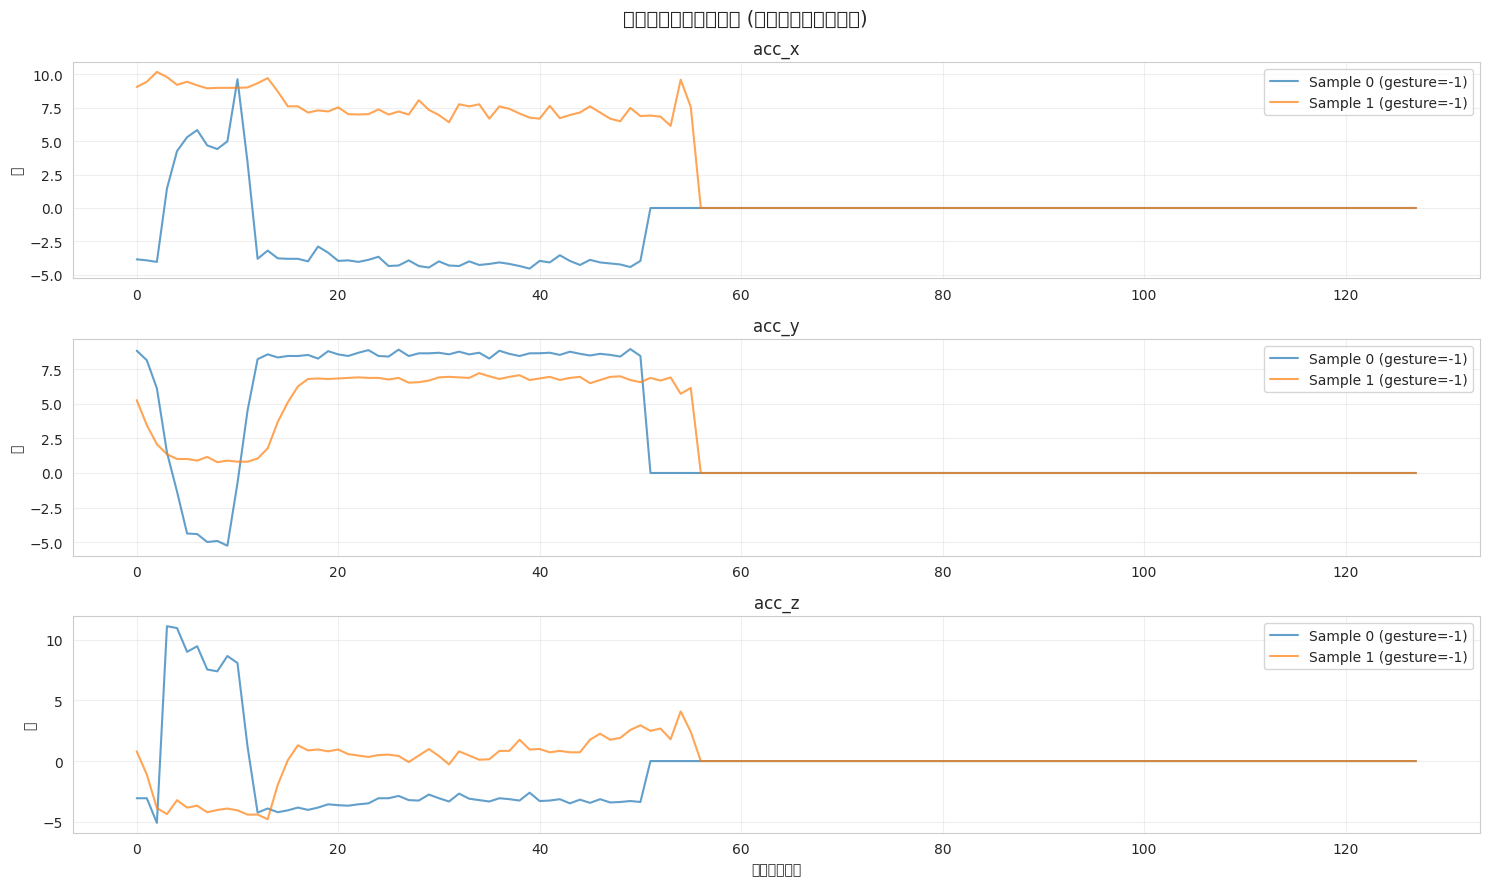

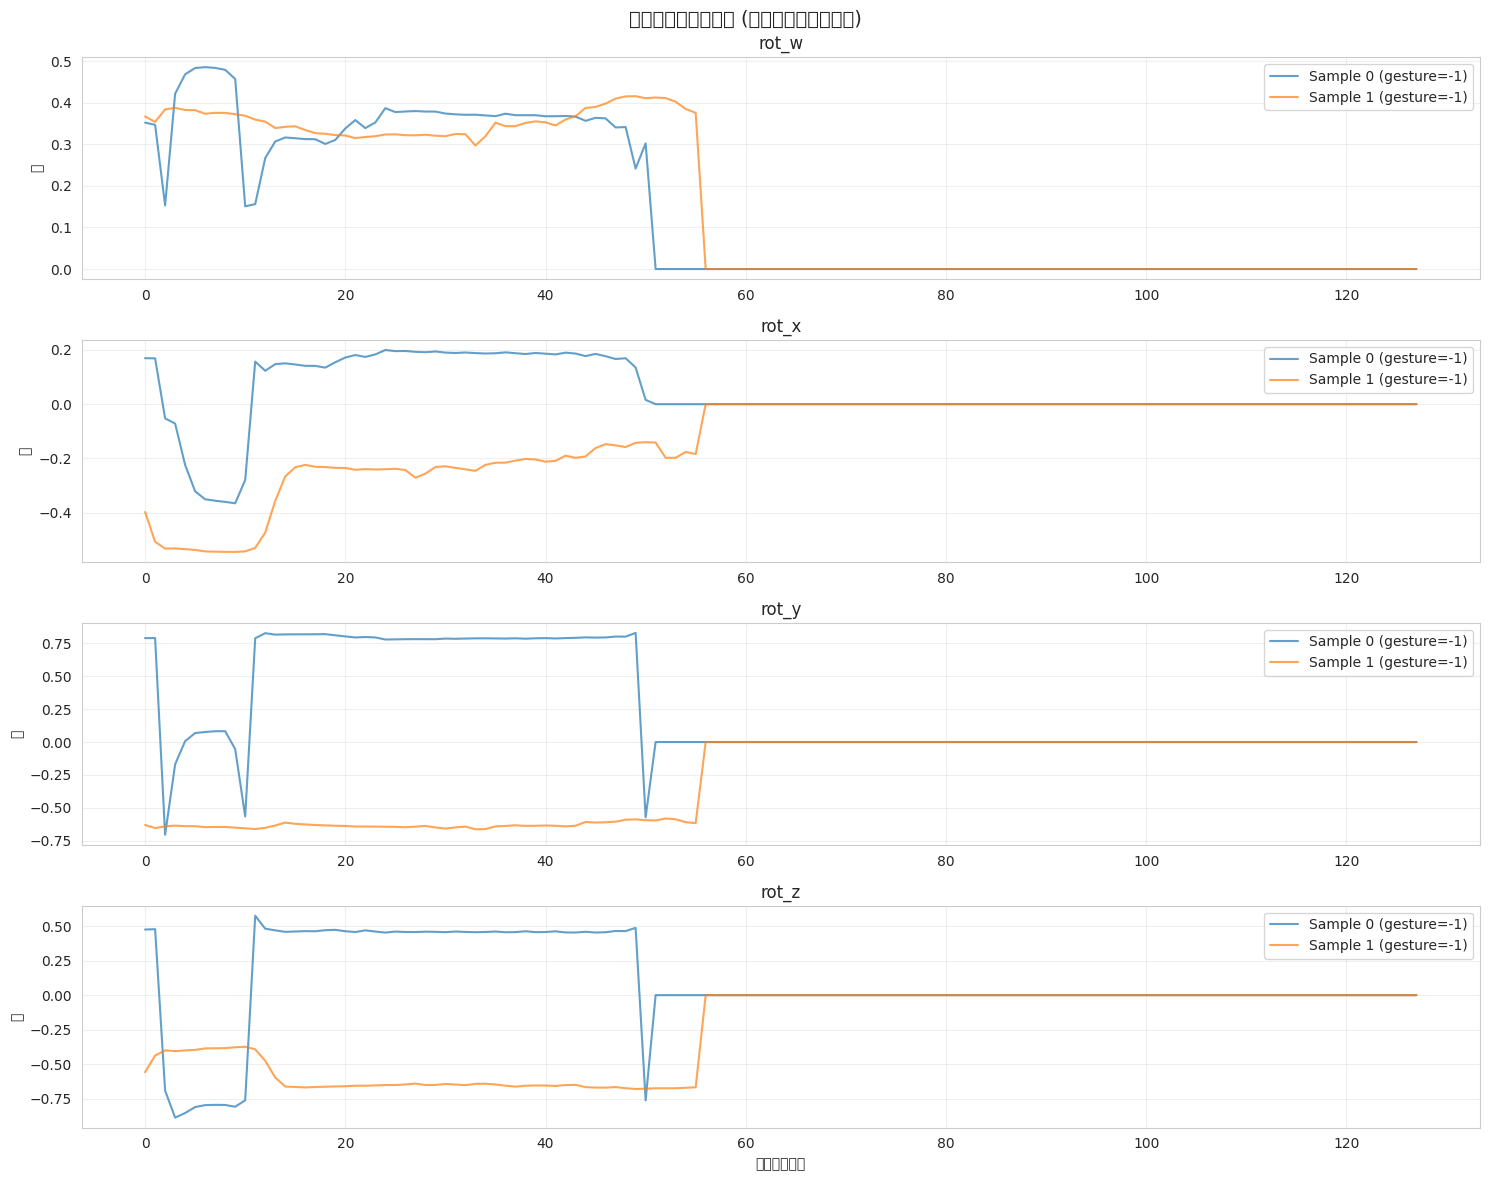

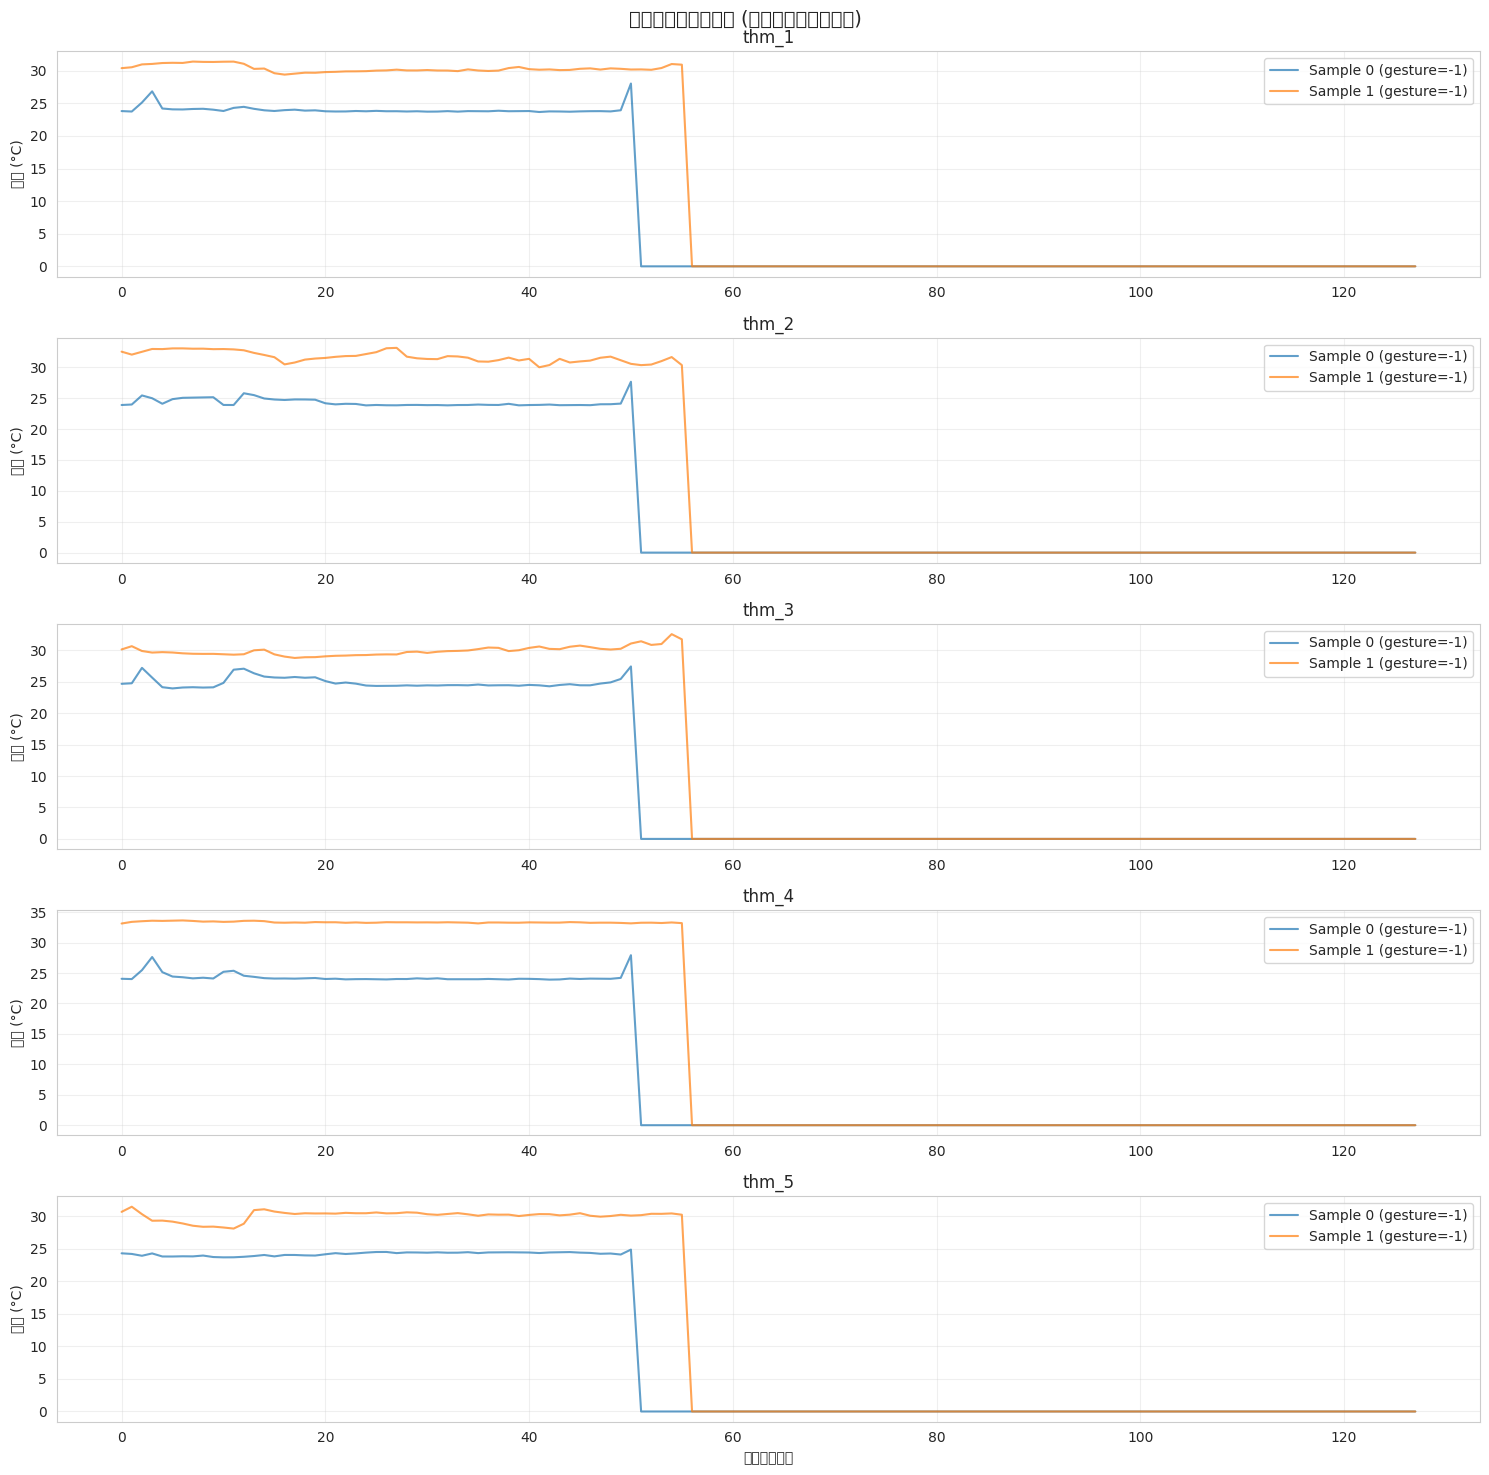


### 人口統計データの分布


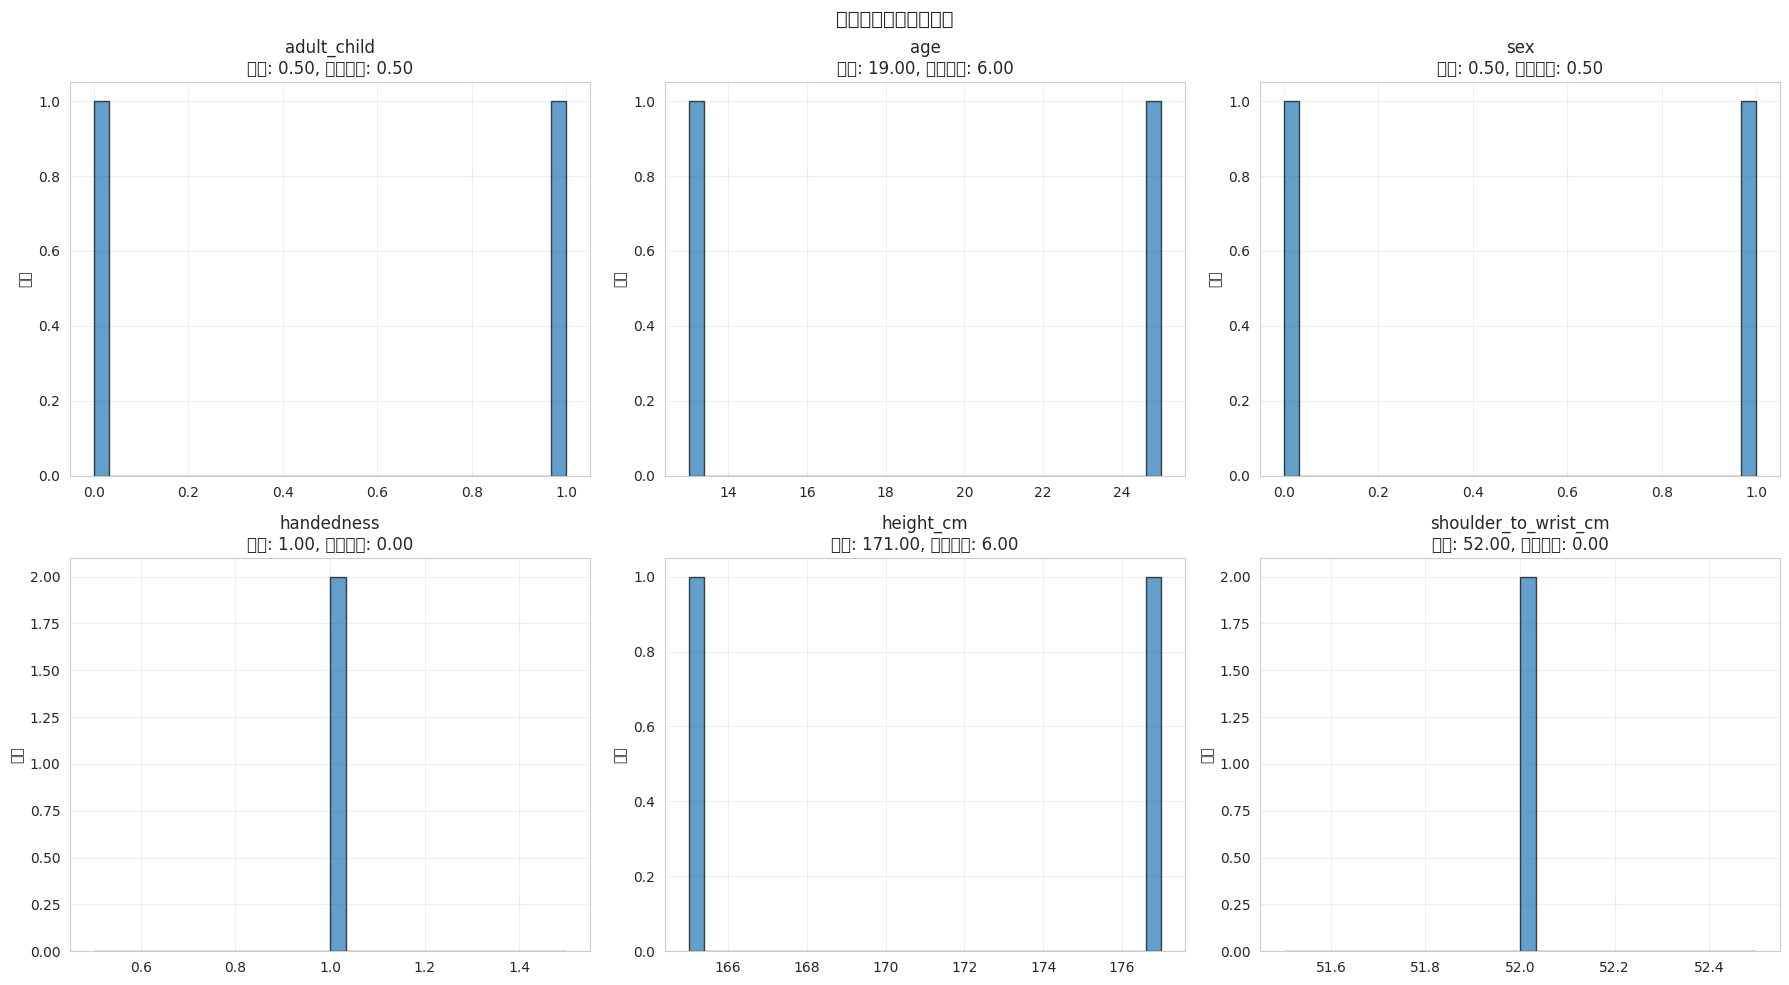


### ジェスチャーごとのセンサーデータ分析
✓ ユニークジェスチャー: [-1]



In [6]:
# センサー別データの可視化
print("### センサー別データの可視化")
print("="*50)

# ウィンドウデータが利用可能な場合の可視化
if 'windows_data' in locals() and windows_data is not None:
    X_sensor, X_demo, y, info = windows_data[:4]
    
    # センサー設定の読み込み
    sensor_acc_cols = config.get("sensor_acc_cols", [])
    sensor_rot_cols = config.get("sensor_rot_cols", [])
    sensor_thm_cols = config.get("sensor_thm_cols", [])
    
    # 全センサー列の推定
    all_sensor_cols = sensor_acc_cols + sensor_rot_cols + sensor_thm_cols
    
    # ToF列の追加（設定から推定）
    tof_depth = config.get("preprocessing", {}).get("tof_depth", 5)
    tof_height = config.get("preprocessing", {}).get("tof_height", 8) 
    tof_width = config.get("preprocessing", {}).get("tof_width", 8)
    tof_cols = [f"tof_{d}_v{i}" for d in range(1, tof_depth + 1) for i in range(tof_height * tof_width)]
    all_sensor_cols.extend(tof_cols)
    
    print(f"✓ センサーウィンドウ形状: {X_sensor.shape}")
    print(f"✓ 想定センサー列数: {len(all_sensor_cols)}")
    
    # サンプルウィンドウの選択（最初の5個）
    n_samples = min(5, X_sensor.shape[0])
    sample_indices = list(range(n_samples))
    
    # 1. 加速度センサーの可視化
    if len(sensor_acc_cols) > 0:
        fig, axes = plt.subplots(len(sensor_acc_cols), 1, figsize=(15, 3*len(sensor_acc_cols)))
        if len(sensor_acc_cols) == 1:
            axes = [axes]
        
        fig.suptitle("加速度センサーデータ (サンプルウィンドウ)", fontsize=14, y=0.98)
        
        for i, col_name in enumerate(sensor_acc_cols):
            if i < X_sensor.shape[-1]:
                for sample_idx in sample_indices:
                    window_data = X_sensor[sample_idx, :, i]
                    axes[i].plot(window_data, alpha=0.7, label=f"Sample {sample_idx} (gesture={y[sample_idx]})")
                
                axes[i].set_title(f"{col_name}")
                axes[i].set_ylabel("値")
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
        
        axes[-1].set_xlabel("時間ステップ")
        plt.tight_layout()
        plt.show()
    
    # 2. 回転センサーの可視化
    if len(sensor_rot_cols) > 0:
        acc_offset = len(sensor_acc_cols)
        
        fig, axes = plt.subplots(len(sensor_rot_cols), 1, figsize=(15, 3*len(sensor_rot_cols)))
        if len(sensor_rot_cols) == 1:
            axes = [axes]
        
        fig.suptitle("回転センサーデータ (サンプルウィンドウ)", fontsize=14, y=0.98)
        
        for i, col_name in enumerate(sensor_rot_cols):
            sensor_idx = acc_offset + i
            if sensor_idx < X_sensor.shape[-1]:
                for sample_idx in sample_indices:
                    window_data = X_sensor[sample_idx, :, sensor_idx]
                    axes[i].plot(window_data, alpha=0.7, label=f"Sample {sample_idx} (gesture={y[sample_idx]})")
                
                axes[i].set_title(f"{col_name}")
                axes[i].set_ylabel("値")
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
        
        axes[-1].set_xlabel("時間ステップ")
        plt.tight_layout()
        plt.show()
    
    # 3. 温度センサーの可視化
    if len(sensor_thm_cols) > 0:
        thm_offset = len(sensor_acc_cols) + len(sensor_rot_cols)
        
        fig, axes = plt.subplots(len(sensor_thm_cols), 1, figsize=(15, 3*len(sensor_thm_cols)))
        if len(sensor_thm_cols) == 1:
            axes = [axes]
        
        fig.suptitle("温度センサーデータ (サンプルウィンドウ)", fontsize=14, y=0.98)
        
        for i, col_name in enumerate(sensor_thm_cols):
            sensor_idx = thm_offset + i
            if sensor_idx < X_sensor.shape[-1]:
                for sample_idx in sample_indices:
                    window_data = X_sensor[sample_idx, :, sensor_idx]
                    axes[i].plot(window_data, alpha=0.7, label=f"Sample {sample_idx} (gesture={y[sample_idx]})")
                
                axes[i].set_title(f"{col_name}")
                axes[i].set_ylabel("温度 (°C)")
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
        
        axes[-1].set_xlabel("時間ステップ")
        plt.tight_layout()
        plt.show()
    
    # 4. 人口統計データの分布
    print("\n### 人口統計データの分布")
    demo_cols = config.get("demographics_cols", [])
    if X_demo.shape[1] > 0:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        
        for i in range(min(X_demo.shape[1], len(axes))):
            values = X_demo[:, i]
            demo_col_name = demo_cols[i] if i < len(demo_cols) else f"demo_{i}"
            
            # ヒストグラム
            axes[i].hist(values, bins=30, alpha=0.7, edgecolor='black')
            axes[i].set_title(f"{demo_col_name}\n平均: {np.mean(values):.2f}, 標準偏差: {np.std(values):.2f}")
            axes[i].set_ylabel("頻度")
            axes[i].grid(True, alpha=0.3)
        
        # 未使用のサブプロットを非表示
        for i in range(X_demo.shape[1], len(axes)):
            axes[i].set_visible(False)
        
        plt.suptitle("人口統計データの分布", fontsize=14)
        plt.tight_layout()
        plt.show()
    
    # 5. ジェスチャーごとのセンサーデータ分布
    print("\n### ジェスチャーごとのセンサーデータ分析")
    unique_gestures = np.unique(y)
    print(f"✓ ユニークジェスチャー: {unique_gestures}")
    
    if len(unique_gestures) > 1 and len(sensor_acc_cols) > 0:
        # 加速度データの平均値をジェスチャー別に比較
        fig, axes = plt.subplots(1, len(sensor_acc_cols), figsize=(5*len(sensor_acc_cols), 6))
        if len(sensor_acc_cols) == 1:
            axes = [axes]
        
        for i, col_name in enumerate(sensor_acc_cols):
            if i < X_sensor.shape[-1]:
                gesture_means = []
                gesture_labels = []
                
                for gesture in unique_gestures:
                    mask = (y == gesture)
                    if np.sum(mask) > 0:
                        gesture_data = X_sensor[mask, :, i]
                        mean_values = np.mean(gesture_data, axis=1)  # 各ウィンドウの平均
                        gesture_means.append(mean_values)
                        gesture_labels.append(f"Gesture {gesture}")
                
                # ボックスプロット
                axes[i].boxplot(gesture_means, labels=gesture_labels)
                axes[i].set_title(f"{col_name} - ジェスチャー別分布")
                axes[i].set_ylabel("平均値")
                axes[i].grid(True, alpha=0.3)
        
        plt.suptitle("ジェスチャー別センサーデータ分布", fontsize=14)
        plt.tight_layout()
        plt.show()

else:
    print("❌ ウィンドウデータが利用できないため、可視化をスキップします")

print("\n" + "="*60)


### ToFデータの可視化
✓ ToFボクセルデータ形状: (107, 5, 8, 8)
✓ ToF設定: 5層 × 8×8ピクセル


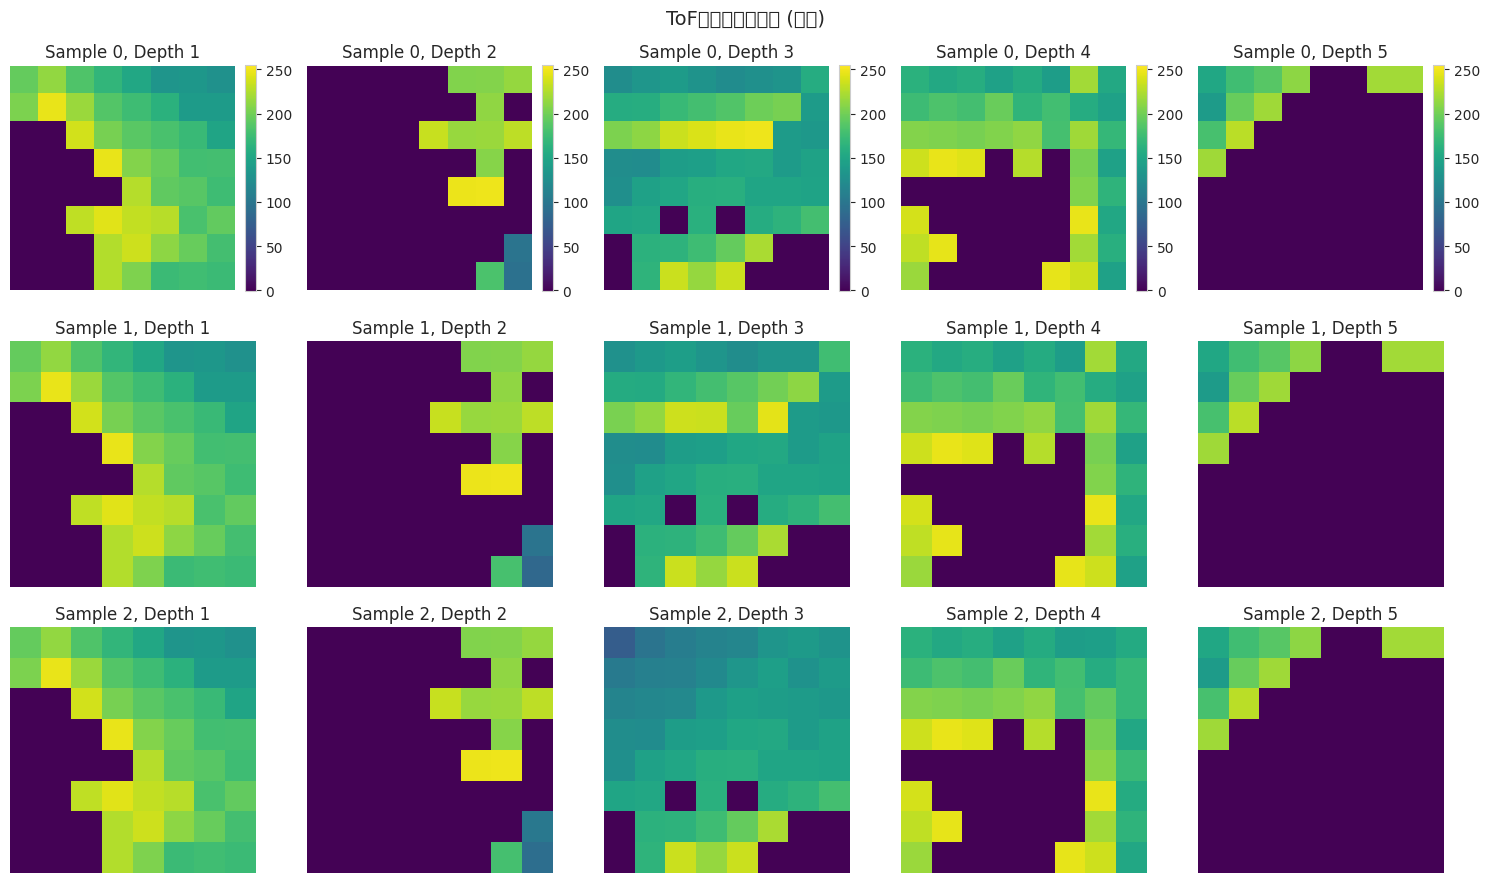


### ToFボクセル統計
✓ 全体統計:
  └ 最小値: 0.00
  └ 最大値: 249.00
  └ 平均値: 58.58
  └ 標準偏差: 81.59
✓ 層1統計:
  └ 平均値: 41.51
  └ 標準偏差: 72.04
  └ -1値の割合: 0.0%
  └ 0値の割合: 43.9%
✓ 層2統計:
  └ 平均値: 20.61
  └ 標準偏差: 44.69
  └ -1値の割合: 0.0%
  └ 0値の割合: 54.4%
✓ 層3統計:
  └ 平均値: 60.46
  └ 標準偏差: 85.73
  └ -1値の割合: 0.0%
  └ 0値の割合: 54.0%
✓ 層4統計:
  └ 平均値: 93.20
  └ 標準偏差: 91.80
  └ -1値の割合: 0.0%
  └ 0値の割合: 45.1%
✓ 層5統計:
  └ 平均値: 77.12
  └ 標準偏差: 83.89
  └ -1値の割合: 0.0%
  └ 0値の割合: 50.1%
ToFウィンドウデータの構造: <class 'tuple'>, 長さ: 2
✓ ToFウィンドウデータは2要素（データ本体, infoリスト）です

### ToFウィンドウデータ
✓ ToFウィンドウ形状: (2, 128, 5, 8, 8)
✓ 情報件数: 2


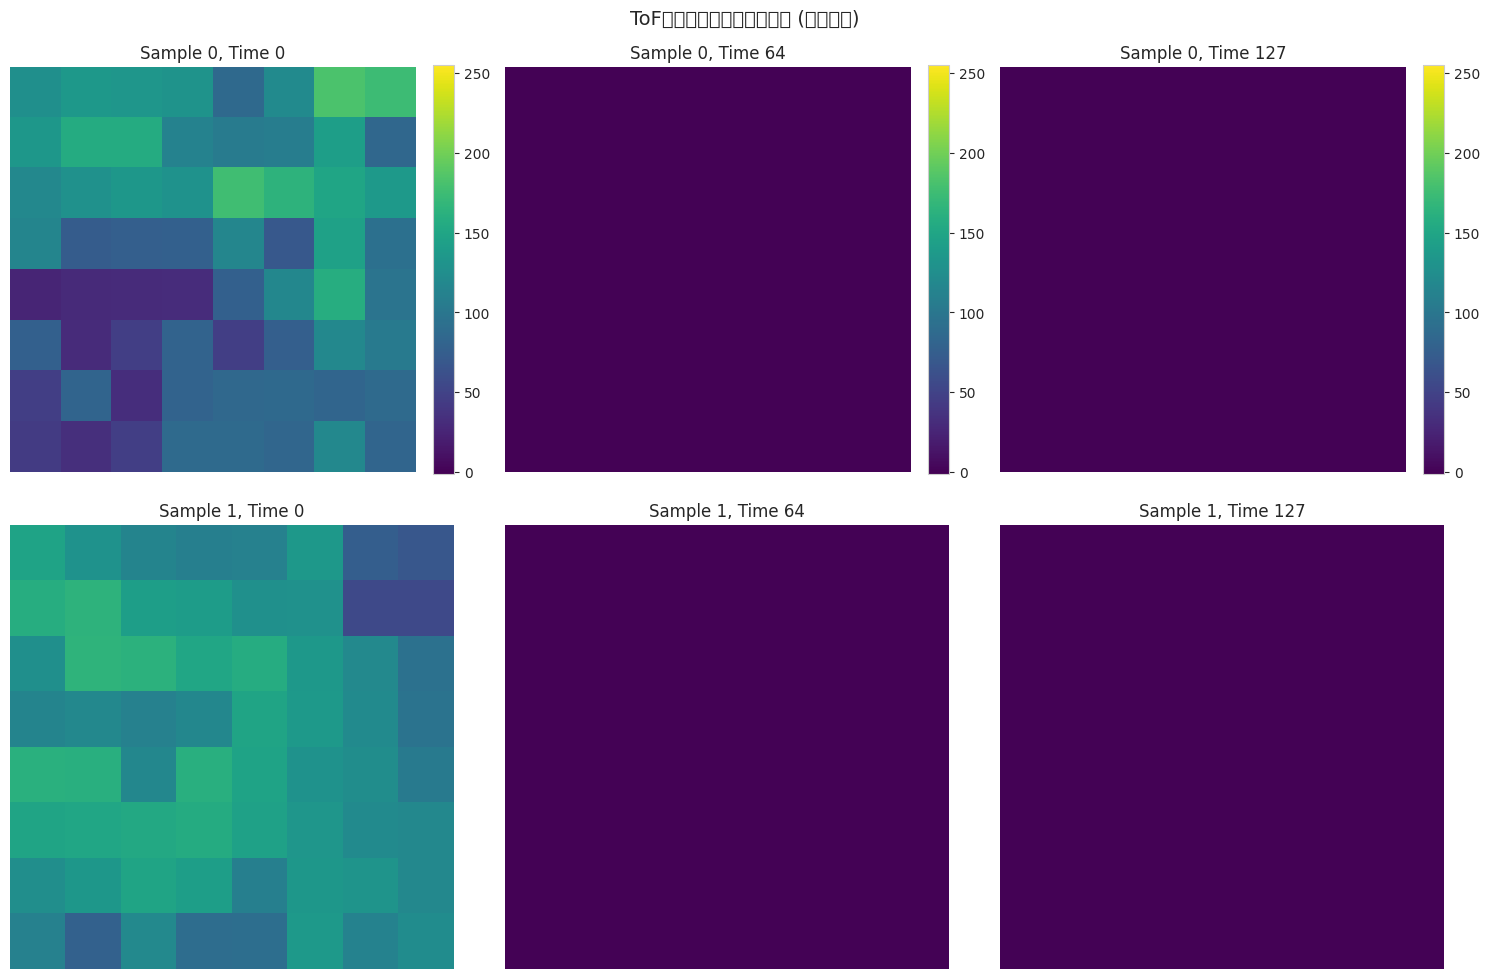


### 表形式特徴量におけるToF成分
✓ 特徴量数: 129


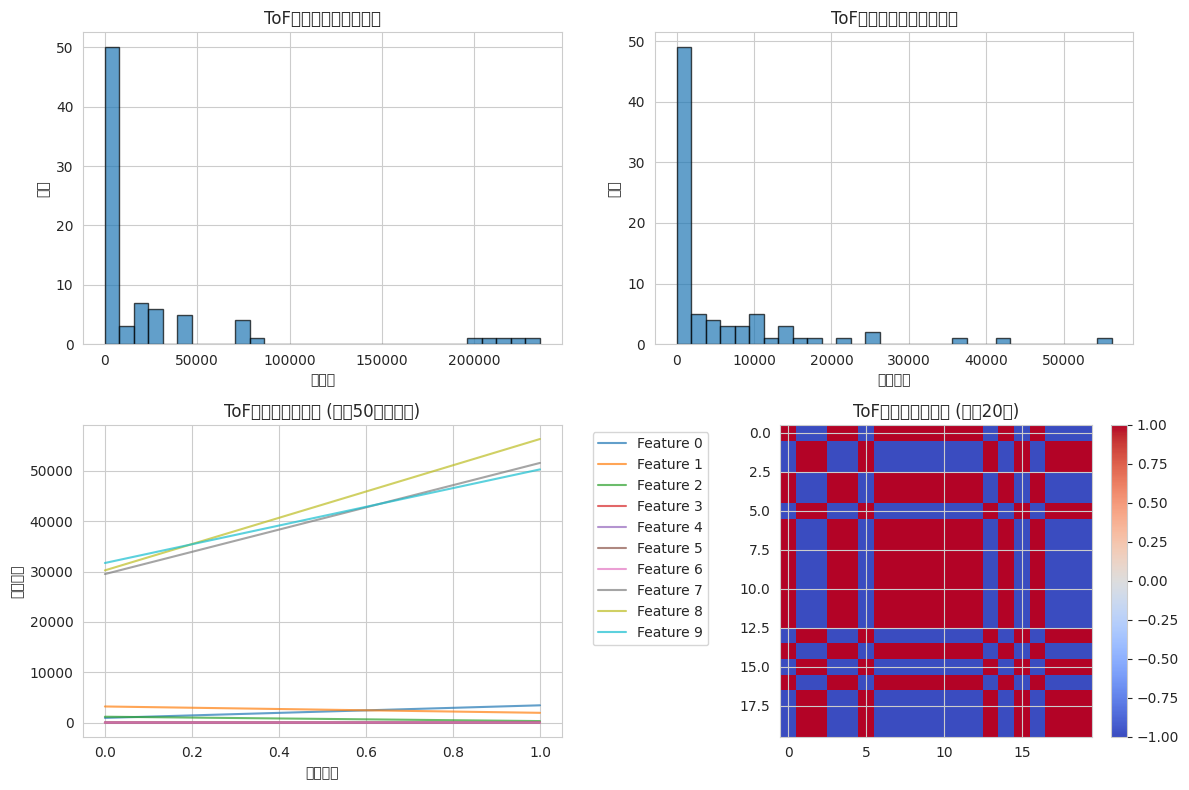

In [8]:
# ToFデータの可視化
print("### ToFデータの可視化")
print("="*50)

# ToFボクセルデータの可視化
if 'tof_voxel_data' in locals() and tof_voxel_data is not None:
    print(f"✓ ToFボクセルデータ形状: {tof_voxel_data.shape}")
    
    # ToF設定値
    tof_depth = config.get("preprocessing", {}).get("tof_depth", 5)
    tof_height = config.get("preprocessing", {}).get("tof_height", 8)
    tof_width = config.get("preprocessing", {}).get("tof_width", 8)
    
    print(f"✓ ToF設定: {tof_depth}層 × {tof_height}×{tof_width}ピクセル")
    
    if len(tof_voxel_data.shape) >= 4:  # (samples, depth, height, width)
        # サンプル数個のToFボクセルを可視化
        n_samples = min(3, tof_voxel_data.shape[0])
        
        fig, axes = plt.subplots(n_samples, tof_depth, figsize=(3*tof_depth, 3*n_samples))
        if n_samples == 1:
            axes = axes.reshape(1, -1)
        if tof_depth == 1:
            axes = axes.reshape(-1, 1)
        
        for sample_idx in range(n_samples):
            for depth_idx in range(tof_depth):
                image_data = tof_voxel_data[sample_idx, depth_idx, :, :]
                
                im = axes[sample_idx, depth_idx].imshow(image_data, cmap='viridis', vmin=-1, vmax=255)
                axes[sample_idx, depth_idx].set_title(f"Sample {sample_idx}, Depth {depth_idx+1}")
                axes[sample_idx, depth_idx].axis('off')
                
                # カラーバー（最初の行のみ）
                if sample_idx == 0:
                    plt.colorbar(im, ax=axes[sample_idx, depth_idx], fraction=0.046, pad=0.04)
        
        plt.suptitle("ToFボクセル可視化 (各層)", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # ToFデータの統計情報
        print("\n### ToFボクセル統計")
        print(f"✓ 全体統計:")
        print(f"  └ 最小値: {np.nanmin(tof_voxel_data):.2f}")
        print(f"  └ 最大値: {np.nanmax(tof_voxel_data):.2f}")
        print(f"  └ 平均値: {np.nanmean(tof_voxel_data):.2f}")
        print(f"  └ 標準偏差: {np.nanstd(tof_voxel_data):.2f}")
        
        # 各層の統計
        for depth_idx in range(tof_depth):
            layer_data = tof_voxel_data[:, depth_idx, :, :]
            print(f"✓ 層{depth_idx+1}統計:")
            print(f"  └ 平均値: {np.nanmean(layer_data):.2f}")
            print(f"  └ 標準偏差: {np.nanstd(layer_data):.2f}")
            print(f"  └ -1値の割合: {(layer_data == -1).sum() / layer_data.size * 100:.1f}%")
            print(f"  └ 0値の割合: {(layer_data == 0).sum() / layer_data.size * 100:.1f}%")

# ToFウィンドウデータの可視化
if 'tof_windows_data' in locals() and tof_windows_data is not None:
    print(f"ToFウィンドウデータの構造: {type(tof_windows_data)}, 長さ: {len(tof_windows_data)}")
    
    # 2要素タプル（データ本体, infoリスト）としてアンパック
    if len(tof_windows_data) == 2:
        tof_X, tof_info = tof_windows_data
        print("✓ ToFウィンドウデータは2要素（データ本体, infoリスト）です")
    else:
        print("❌ ToFウィンドウデータの構造が想定外です")
        tof_X, tof_info = None, None

    if tof_X is not None and tof_info is not None:
        print(f"\n### ToFウィンドウデータ")
        print(f"✓ ToFウィンドウ形状: {tof_X.shape}")
        print(f"✓ 情報件数: {len(tof_info)}")
        
        # ラベル情報が必要な場合は info から取得するか、別途ラベルファイルを参照
        # ここではラベルが無い前提で可視化のみ行う
        if len(tof_X.shape) == 5:  # (samples, time, depth, height, width)
            n_samples = min(2, tof_X.shape[0])
            time_steps = [0, tof_X.shape[1]//2, tof_X.shape[1]-1]
            
            fig, axes = plt.subplots(n_samples, len(time_steps), figsize=(5*len(time_steps), 5*n_samples))
            if n_samples == 1:
                axes = axes.reshape(1, -1)
            
            for sample_idx in range(n_samples):
                for i, time_step in enumerate(time_steps):
                    image_data = np.mean(tof_X[sample_idx, time_step, :, :, :], axis=0)
                    im = axes[sample_idx, i].imshow(image_data, cmap='viridis', vmin=-1, vmax=255)
                    axes[sample_idx, i].set_title(f"Sample {sample_idx}, Time {time_step}")
                    axes[sample_idx, i].axis('off')
                    if sample_idx == 0:
                        plt.colorbar(im, ax=axes[sample_idx, i], fraction=0.046, pad=0.04)
            
            plt.suptitle("ToFウィンドウ時系列可視化 (全層平均)", fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print("❌ ToFウィンドウデータのshapeが想定外です")
    else:
        print("❌ ToFウィンドウデータの処理をスキップします")

# 特徴量データでのToF可視化
if 'tabular_data' in locals() and tabular_data is not None:
    features, y_tab, info_tab = tabular_data[:3]
    
    print(f"\n### 表形式特徴量におけるToF成分")
    print(f"✓ 特徴量数: {features.shape[1]}")
    
    # ToF関連特徴量の推定（最後の方にある可能性）
    tof_feature_start = len(config.get("sensor_acc_cols", [])) * 4  # 基本統計量の数
    tof_feature_start += len(config.get("sensor_rot_cols", [])) * 4
    tof_feature_start += len(config.get("sensor_thm_cols", [])) * 4
    
    if features.shape[1] > tof_feature_start:
        # ToF特徴量の分布確認
        tof_features = features[:, tof_feature_start:]
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()
        
        # 特徴量の基本統計をプロット
        if tof_features.shape[1] > 0:
            # 平均値の分布
            feature_means = np.nanmean(tof_features, axis=0)
            axes[0].hist(feature_means, bins=30, alpha=0.7, edgecolor='black')
            axes[0].set_title("ToF特徴量の平均値分布")
            axes[0].set_xlabel("平均値")
            axes[0].set_ylabel("頻度")
            
            # 標準偏差の分布
            feature_stds = np.nanstd(tof_features, axis=0)
            axes[1].hist(feature_stds, bins=30, alpha=0.7, edgecolor='black')
            axes[1].set_title("ToF特徴量の標準偏差分布")
            axes[1].set_xlabel("標準偏差")
            axes[1].set_ylabel("頻度")
            
            # サンプル特徴量の時系列（最初の10個）
            n_features_to_plot = min(10, tof_features.shape[1])
            for i in range(n_features_to_plot):
                axes[2].plot(tof_features[:50, i], alpha=0.7, label=f"Feature {i}")
            axes[2].set_title("ToF特徴量の値変化 (最初50サンプル)")
            axes[2].set_xlabel("サンプル")
            axes[2].set_ylabel("特徴量値")
            axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
            # 相関行列（最初の20個の特徴量）
            if tof_features.shape[1] > 1:
                n_corr = min(20, tof_features.shape[1])
                corr_matrix = np.corrcoef(tof_features[:, :n_corr].T)
                im = axes[3].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
                axes[3].set_title(f"ToF特徴量相関行列 (最初{n_corr}個)")
                plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()

else:
    print("❌ ToFデータが利用できないため、可視化をスキップします")

print("\n" + "="*60)


### 欠損値処理と前後比較
### 生データの欠損値状況
✓ accelerometer: 0.00% (0/3000)
✓ rotation: 0.00% (0/4000)
✓ tof: 0.00% (0/320000)
✓ thermal: 0.00% (0/5000)

### 処理済みデータの欠損値状況
✓ センサーデータ: 0.00% (0/3072)
✓ 人口統計データ: 0.00% (0/14)
✓ 表形式特徴量: 0.00% (0/258)

### 欠損値処理効果の可視化


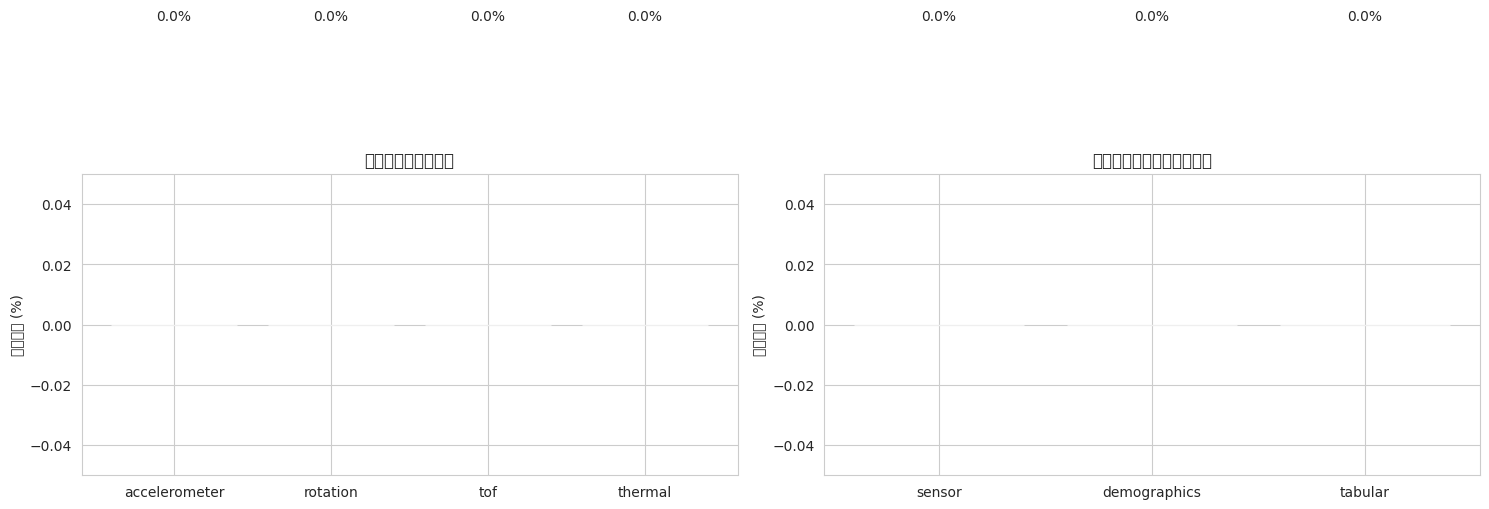


### データ値範囲の比較
#### 生データ (サンプル)
✓ accelerometer:
  └ 範囲: [-12.789, 14.746]
  └ 平均: 1.243
  └ 標準偏差: 5.615
✓ rotation:
  └ 範囲: [-0.944, 0.947]
  └ 平均: -0.098
  └ 標準偏差: 0.490
✓ tof:
  └ 範囲: [-1.000, 249.000]
  └ 平均: 50.476
  └ 標準偏差: 69.003
✓ thermal:
  └ 範囲: [22.966, 36.706]
  └ 平均: 27.909
  └ 標準偏差: 2.855

#### 処理済みデータ (ウィンドウ)
✓ センサーデータ:
  └ 範囲: [-5.258, 33.649]
  └ 平均: 5.141
  └ 標準偏差: 10.714
✓ 人口統計データ:
  └ 範囲: [0.000, 177.000]
  └ 平均: 38.429
  └ 標準偏差: 56.911



In [10]:
# 欠損値処理と前後比較
print("### 欠損値処理と前後比較")
print("="*50)

# 生データとキャッシュデータの比較
if 'train_sample' in locals():
    print("### 生データの欠損値状況")
    
    # センサー別の欠損値率
    sensor_types = {
        'accelerometer': [col for col in train_sample.columns if col.startswith('acc_')],
        'rotation': [col for col in train_sample.columns if col.startswith('rot_')], 
        'tof': [col for col in train_sample.columns if col.startswith('tof_')],
        'thermal': [col for col in train_sample.columns if col.startswith('thm_')]
    }
    
    raw_missing_stats = {}
    for sensor_type, cols in sensor_types.items():
        if len(cols) > 0:
            missing_count = train_sample[cols].isnull().sum().sum()
            total_count = len(train_sample) * len(cols)
            missing_ratio = missing_count / total_count * 100
            raw_missing_stats[sensor_type] = {
                'missing_count': missing_count,
                'total_count': total_count,
                'missing_ratio': missing_ratio
            }
            print(f"✓ {sensor_type}: {missing_ratio:.2f}% ({missing_count}/{total_count})")

# 処理済みデータの欠損値状況
processed_missing_stats = {}
if 'windows_data' in locals() and windows_data is not None:
    X_sensor, X_demo, y, info = windows_data[:4]
    
    print(f"\n### 処理済みデータの欠損値状況")
    
    # センサーデータ
    sensor_nan_count = np.isnan(X_sensor).sum()
    sensor_total_count = X_sensor.size
    sensor_nan_ratio = sensor_nan_count / sensor_total_count * 100
    
    print(f"✓ センサーデータ: {sensor_nan_ratio:.2f}% ({sensor_nan_count}/{sensor_total_count})")
    
    # 人口統計データ
    demo_nan_count = np.isnan(X_demo).sum()
    demo_total_count = X_demo.size
    demo_nan_ratio = demo_nan_count / demo_total_count * 100
    
    print(f"✓ 人口統計データ: {demo_nan_ratio:.2f}% ({demo_nan_count}/{demo_total_count})")
    
    processed_missing_stats['sensor'] = {
        'missing_count': sensor_nan_count,
        'total_count': sensor_total_count,
        'missing_ratio': sensor_nan_ratio
    }
    processed_missing_stats['demographics'] = {
        'missing_count': demo_nan_count,
        'total_count': demo_total_count,
        'missing_ratio': demo_nan_ratio
    }

# 特徴量データの欠損値状況
if 'tabular_data' in locals() and tabular_data is not None:
    features, y_tab, info_tab = tabular_data[:3]
    
    tab_nan_count = np.isnan(features).sum()
    tab_total_count = features.size
    tab_nan_ratio = tab_nan_count / tab_total_count * 100
    
    print(f"✓ 表形式特徴量: {tab_nan_ratio:.2f}% ({tab_nan_count}/{tab_total_count})")
    
    processed_missing_stats['tabular'] = {
        'missing_count': tab_nan_count,
        'total_count': tab_total_count,
        'missing_ratio': tab_nan_ratio
    }

# 欠損値処理の効果を可視化
if 'raw_missing_stats' in locals() and processed_missing_stats:
    print(f"\n### 欠損値処理効果の可視化")
    
    # 比較グラフの作成
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 生データの欠損値率
    if raw_missing_stats:
        sensor_names = list(raw_missing_stats.keys())
        raw_ratios = [raw_missing_stats[name]['missing_ratio'] for name in sensor_names]
        
        bars1 = ax1.bar(sensor_names, raw_ratios, alpha=0.7, color='red', label='処理前')
        ax1.set_title('生データの欠損値率')
        ax1.set_ylabel('欠損値率 (%)')
        ax1.set_ylim(0, max(raw_ratios) * 1.1 if raw_ratios else 1)
        
        # 値をバーの上に表示
        for bar, ratio in zip(bars1, raw_ratios):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{ratio:.1f}%', ha='center', va='bottom')
    
    # 処理済みデータの欠損値率
    if processed_missing_stats:
        proc_names = list(processed_missing_stats.keys())
        proc_ratios = [processed_missing_stats[name]['missing_ratio'] for name in proc_names]
        
        bars2 = ax2.bar(proc_names, proc_ratios, alpha=0.7, color='blue', label='処理後')
        ax2.set_title('処理済みデータの欠損値率')
        ax2.set_ylabel('欠損値率 (%)')
        ax2.set_ylim(0, max(proc_ratios) * 1.1 if proc_ratios else 1)
        
        # 値をバーの上に表示
        for bar, ratio in zip(bars2, proc_ratios):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{ratio:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# データ値の範囲比較
print(f"\n### データ値範囲の比較")

# 生データのサンプル統計
if 'train_sample' in locals():
    print("#### 生データ (サンプル)")
    for sensor_type, cols in sensor_types.items():
        if len(cols) > 0 and cols[0] in train_sample.columns:
            values = train_sample[cols].values.flatten()
            values_clean = values[~pd.isna(values)]
            if len(values_clean) > 0:
                print(f"✓ {sensor_type}:")
                print(f"  └ 範囲: [{np.min(values_clean):.3f}, {np.max(values_clean):.3f}]")
                print(f"  └ 平均: {np.mean(values_clean):.3f}")
                print(f"  └ 標準偏差: {np.std(values_clean):.3f}")

# 処理済みデータの統計
if 'windows_data' in locals() and windows_data is not None:
    print(f"\n#### 処理済みデータ (ウィンドウ)")
    X_sensor, X_demo, y, info = windows_data[:4]
    
    print(f"✓ センサーデータ:")
    print(f"  └ 範囲: [{np.nanmin(X_sensor):.3f}, {np.nanmax(X_sensor):.3f}]")
    print(f"  └ 平均: {np.nanmean(X_sensor):.3f}")
    print(f"  └ 標準偏差: {np.nanstd(X_sensor):.3f}")
    
    print(f"✓ 人口統計データ:")
    print(f"  └ 範囲: [{np.nanmin(X_demo):.3f}, {np.nanmax(X_demo):.3f}]")
    print(f"  └ 平均: {np.nanmean(X_demo):.3f}")
    print(f"  └ 標準偏差: {np.nanstd(X_demo):.3f}")

# 正規化効果の確認
if 'preprocessed_dir' in locals() and preprocessed_dir is not None:
    print(f"\n### 正規化効果の確認")
    
    # 訓練データのセンサーデータを読み込み
    try:
        train_sensor_files = [f for f in preprocessed_dir.glob("train_*.pkl") if 'sensor' in f.name]
        if train_sensor_files:
            with open(train_sensor_files[0], 'rb') as f:
                train_sensor_normalized = pickle.load(f)
            
            if isinstance(train_sensor_normalized, np.ndarray):
                print(f"✓ 正規化済みセンサーデータ:")
                print(f"  └ 形状: {train_sensor_normalized.shape}")
                print(f"  └ 範囲: [{np.nanmin(train_sensor_normalized):.3f}, {np.nanmax(train_sensor_normalized):.3f}]")
                print(f"  └ 平均: {np.nanmean(train_sensor_normalized):.3f}")
                print(f"  └ 標準偏差: {np.nanstd(train_sensor_normalized):.3f}")
                
                # 正規化データの分布可視化
                if train_sensor_normalized.size < 1000000:  # メモリ節約のため
                    sample_values = train_sensor_normalized.flatten()
                    sample_values = sample_values[~np.isnan(sample_values)]
                    
                    if len(sample_values) > 1000:
                        sample_values = np.random.choice(sample_values, 1000, replace=False)
                    
                    plt.figure(figsize=(12, 4))
                    
                    plt.subplot(1, 2, 1)
                    plt.hist(sample_values, bins=50, alpha=0.7, edgecolor='black')
                    plt.title('正規化後のセンサーデータ分布')
                    plt.xlabel('値')
                    plt.ylabel('頻度')
                    plt.grid(True, alpha=0.3)
                    
                    plt.subplot(1, 2, 2)
                    plt.boxplot(sample_values)
                    plt.title('正規化後のセンサーデータ箱ひげ図')
                    plt.ylabel('値')
                    plt.grid(True, alpha=0.3)
                    
                    plt.tight_layout()
                    plt.show()
                    
    except Exception as e:
        print(f"❌ 正規化データの読み込み失敗: {e}")

print("\n" + "="*60)


In [12]:
# 検証結果のサマリー
print("### 前処理キャッシュ検証結果サマリー")
print("="*50)

# 検証項目のチェック結果
validation_results = {
    "設定ファイル": "✓" if 'config' in locals() else "❌",
    "キャッシュファイル": "✓" if any([
        'windows_data' in locals() and windows_data is not None,
        'tabular_data' in locals() and tabular_data is not None,
        'tof_voxel_data' in locals() and tof_voxel_data is not None,
        'tof_windows_data' in locals() and tof_windows_data is not None
    ]) else "❌",
    "前処理済みデータ": "✓" if 'preprocessed_dir' in locals() and preprocessed_dir is not None else "❌",
    "生データ読み込み": "✓" if 'train_sample' in locals() else "❌",
}

print("### チェック項目")
for item, status in validation_results.items():
    print(f"{status} {item}")

# データ形状サマリー
print(f"\n### データ形状サマリー")
if 'windows_data' in locals() and windows_data is not None:
    X_sensor, X_demo, y, info = windows_data[:4]
    print(f"✓ ウィンドウテンソル: {X_sensor.shape}")
    print(f"✓ 人口統計: {X_demo.shape}")
    print(f"✓ ラベル: {y.shape}")
    print(f"✓ ウィンドウ情報: {len(info)} 件")

if 'tabular_data' in locals() and tabular_data is not None:
    features, y_tab, info_tab = tabular_data[:3]
    print(f"✓ 表形式特徴量: {features.shape}")

if 'tof_voxel_data' in locals() and tof_voxel_data is not None:
    print(f"✓ ToFボクセル: {tof_voxel_data.shape}")

if 'tof_windows_data' in locals() and tof_windows_data is not None:
    # 2要素タプル（データ本体, infoリスト）としてアンパック
    if len(tof_windows_data) == 2:
        tof_X, tof_info = tof_windows_data
        print(f"✓ ToFウィンドウ: {tof_X.shape}")
    else:
        print("❌ ToFウィンドウデータの構造が想定外です")

# 設定パラメータサマリー
if 'config' in locals():
    print(f"\n### 設定パラメータサマリー")
    preprocessing_config = config.get('preprocessing', {})
    print(f"✓ ウィンドウサイズ: {preprocessing_config.get('window_size', 'N/A')}")
    print(f"✓ ストライド: {preprocessing_config.get('stride', 'N/A')}")
    print(f"✓ 最小シーケンス長: {preprocessing_config.get('min_sequence_length', 'N/A')}")
    print(f"✓ サンプリングレート: {preprocessing_config.get('sampling_rate', 'N/A')} Hz")
    
    # センサー設定
    print(f"✓ 加速度センサー: {len(config.get('sensor_acc_cols', []))} 軸")
    print(f"✓ 回転センサー: {len(config.get('sensor_rot_cols', []))} 軸")
    print(f"✓ 温度センサー: {len(config.get('sensor_thm_cols', []))} 個")
    
    # ToF設定
    tof_depth = preprocessing_config.get('tof_depth', 5)
    tof_height = preprocessing_config.get('tof_height', 8)
    tof_width = preprocessing_config.get('tof_width', 8)
    print(f"✓ ToFセンサー: {tof_depth}層 × {tof_height}×{tof_width} = {tof_depth * tof_height * tof_width} ピクセル")

# 品質指標
print(f"\n### データ品質指標")

# 欠損値率
if 'processed_missing_stats' in locals():
    for data_type, stats in processed_missing_stats.items():
        ratio = stats['missing_ratio']
        status = "✓" if ratio < 1.0 else "⚠️" if ratio < 5.0 else "❌"
        print(f"{status} {data_type}: {ratio:.2f}% 欠損")

# データ範囲の妥当性
data_range_checks = []
if 'windows_data' in locals() and windows_data is not None:
    X_sensor, X_demo, y, info = windows_data[:4]
    
    # センサーデータの範囲チェック
    sensor_min, sensor_max = np.nanmin(X_sensor), np.nanmax(X_sensor)
    if not (np.isfinite(sensor_min) and np.isfinite(sensor_max)):
        data_range_checks.append("❌ センサーデータに非有限値")
    elif abs(sensor_min) > 1000 or abs(sensor_max) > 1000:
        data_range_checks.append("⚠️ センサーデータの値が大きすぎる可能性")
    else:
        data_range_checks.append("✓ センサーデータ範囲正常")
    
    # ラベルの一意性チェック
    unique_labels = len(np.unique(y))
    if unique_labels > 1:
        data_range_checks.append(f"✓ ラベル種類: {unique_labels} 個")
    else:
        data_range_checks.append("⚠️ ラベルの多様性不足")

for check in data_range_checks:
    print(check)

# 推奨事項
print(f"\n### 推奨事項")
recommendations = []

if 'processed_missing_stats' in locals():
    high_missing = [k for k, v in processed_missing_stats.items() if v['missing_ratio'] > 5.0]
    if high_missing:
        recommendations.append(f"⚠️ 高欠損データ ({', '.join(high_missing)}) の前処理を確認してください")

if validation_results["キャッシュファイル"] == "❌":
    recommendations.append("❌ キャッシュファイルが不足しています。run_preprocessing.pyを実行してください")

if validation_results["前処理済みデータ"] == "❌":
    recommendations.append("❌ 前処理済みデータがありません。実験を実行してください")

if not recommendations:
    recommendations.append("✓ 前処理は正常に実行されています")

for rec in recommendations:
    print(rec)

# 完了メッセージ
print(f"\n" + "="*60)
print(f"検証完了時刻: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("前処理キャッシュ検証が完了しました。")
print("="*60)


### 前処理キャッシュ検証結果サマリー
### チェック項目
✓ 設定ファイル
✓ キャッシュファイル
❌ 前処理済みデータ
✓ 生データ読み込み

### データ形状サマリー
✓ ウィンドウテンソル: (2, 128, 12)
✓ 人口統計: (2, 7)
✓ ラベル: (2,)
✓ ウィンドウ情報: 2 件
✓ 表形式特徴量: (2, 129)
✓ ToFボクセル: (107, 5, 8, 8)
✓ ToFウィンドウ: (2, 128, 5, 8, 8)

### 設定パラメータサマリー
✓ ウィンドウサイズ: 128
✓ ストライド: 64
✓ 最小シーケンス長: 20
✓ サンプリングレート: 50.0 Hz
✓ 加速度センサー: 3 軸
✓ 回転センサー: 4 軸
✓ 温度センサー: 5 個
✓ ToFセンサー: 5層 × 8×8 = 320 ピクセル

### データ品質指標
✓ sensor: 0.00% 欠損
✓ demographics: 0.00% 欠損
✓ tabular: 0.00% 欠損
✓ センサーデータ範囲正常
⚠️ ラベルの多様性不足

### 推奨事項
❌ 前処理済みデータがありません。実験を実行してください

検証完了時刻: 2025-07-15 05:57:37
前処理キャッシュ検証が完了しました。
